# 소매 매장 주간 매출 예측 분석

**목표:** 50개 소매 매장, 20개 부서의 주간 매출(weekly_sales)을 시계열 피처 기반으로 예측  
**데이터:** [Retail Store Sales Forecasting Dataset](https://www.kaggle.com/datasets/noopurbhatt/retail-store-sales-forecasting-dataset)  
**모델:** LightGBM (Gradient Boosting)  
**성공 지표:** RMSE

---

## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import lightgbm as lgb
import json
import warnings
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings('ignore')

fm.fontManager.addfont('/System/Library/Fonts/AppleSDGothicNeo.ttc')
plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

Path('outputs').mkdir(exist_ok=True)
print('환경 설정 완료')

환경 설정 완료


## 1. 데이터 로드 & 병합

In [2]:
sales    = pd.read_csv('data/raw/sales.csv',    parse_dates=['date'])
features = pd.read_csv('data/raw/features.csv', parse_dates=['date'])
stores   = pd.read_csv('data/raw/stores.csv')

print('sales   :', sales.shape)
print('features:', features.shape)
print('stores  :', stores.shape)

sales   : (156000, 5)
features: (7800, 14)
stores  : (50, 4)


In [3]:
df = sales.merge(features, on=['store_id', 'date', 'is_holiday'], how='left')
df = df.merge(stores, on='store_id', how='left')
df = df.sort_values(['store_id', 'department', 'date']).reset_index(drop=True)

print(f'병합 shape: {df.shape}')
print(f'날짜 범위: {df["date"].min().date()} ~ {df["date"].max().date()}')
print(f'매장 수: {df["store_id"].nunique()}, 부서 수: {df["department"].nunique()}')
df.head(3)

병합 shape: (156000, 19)
날짜 범위: 2022-01-01 ~ 2024-12-21
매장 수: 50, 부서 수: 20


,store_id,department,date,weekly_sales,is_holiday,temperature,fuel_price,markdown_1,markdown_2,markdown_3,markdown_4,markdown_5,cpi,unemployment,holiday_name,season,store_type,store_size,region
0,1,1,2022-01-01,119075.96,1,97.57,4.83,10334.49,5905.86,5261.52,7098.43,876.08,203.52,3.32,New Year,Winter,A,213810,North
1,1,1,2022-01-08,35525.05,0,46.03,3.67,1356.75,2486.21,1427.01,983.27,2442.13,196.91,8.62,NaN,Winter,A,213810,North
2,1,1,2022-01-15,14847.56,0,25.96,5.46,3861.22,596.15,22.09,2854.11,3180.86,267.48,8.40,NaN,Winter,A,213810,North


## 2. EDA (탐색적 데이터 분석)

In [4]:
df['weekly_sales'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
weekly_sales,156000.0,56503.488802,46717.490663,819.66,21255.9625,43394.87,79604.1075,505958.73


### 2-1. 전체 주간 매출 추이

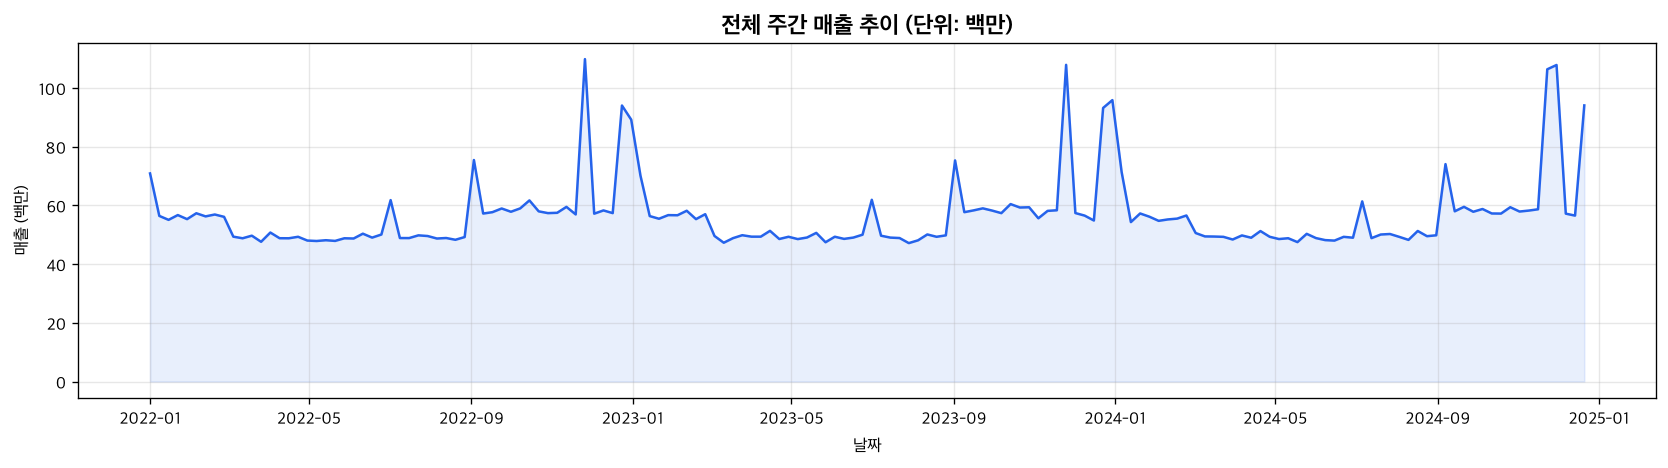

In [5]:
weekly = df.groupby('date')['weekly_sales'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(weekly['date'], weekly['weekly_sales'] / 1e6, color='#2563EB', linewidth=1.5)
ax.fill_between(weekly['date'], weekly['weekly_sales'] / 1e6, alpha=0.1, color='#2563EB')
ax.set_title('전체 주간 매출 추이 (단위: 백만)', fontsize=14, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('매출 (백만)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 2-2. 매장 타입 / 시즌 / 휴일별 매출

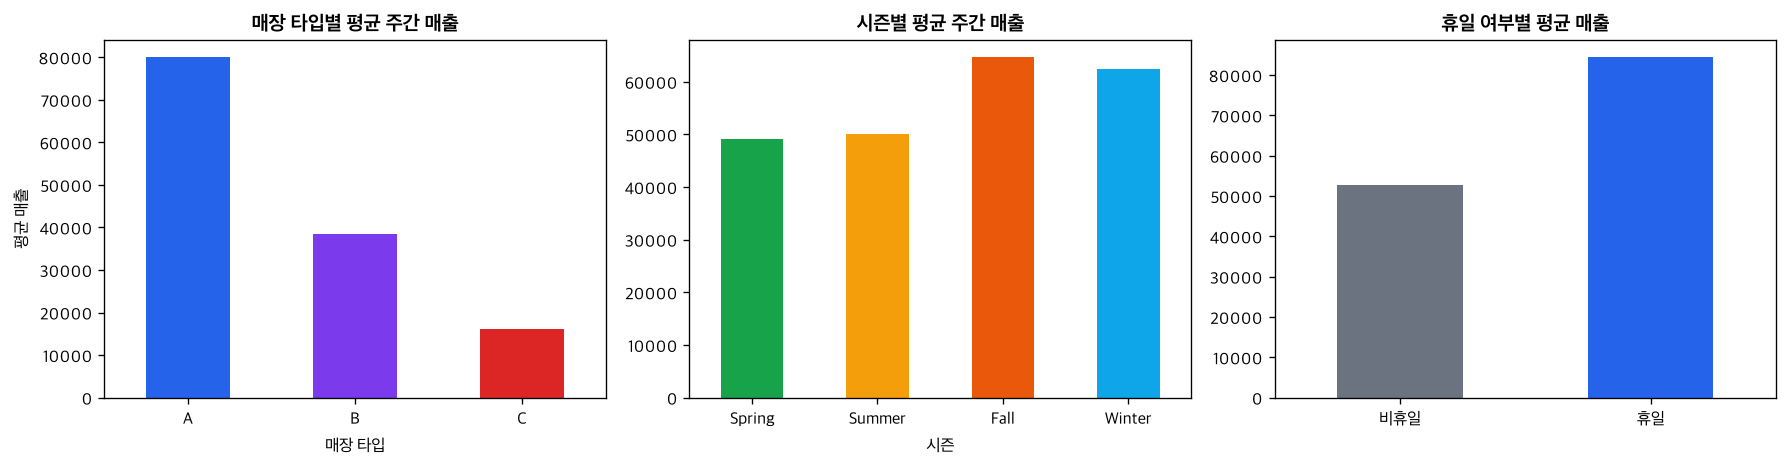

가설 검증:
  휴일 매출 > 비휴일: True (휴일 84,494 vs 비휴일 52,853)
  최고 매출 시즌: Fall (64,706)
  매장 타입 순서: ['A', 'B', 'C']


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 매장 타입
store_type_sales = df.groupby('store_type')['weekly_sales'].mean().sort_values(ascending=False)
store_type_sales.plot(kind='bar', ax=axes[0], color=['#2563EB', '#7C3AED', '#DC2626'])
axes[0].set_title('매장 타입별 평균 주간 매출', fontweight='bold')
axes[0].set_xlabel('매장 타입')
axes[0].set_ylabel('평균 매출')
axes[0].tick_params(axis='x', rotation=0)

# 시즌
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_sales = df.groupby('season')['weekly_sales'].mean().reindex(season_order)
season_sales.plot(kind='bar', ax=axes[1], color=['#16A34A', '#F59E0B', '#EA580C', '#0EA5E9'])
axes[1].set_title('시즌별 평균 주간 매출', fontweight='bold')
axes[1].set_xlabel('시즌')
axes[1].tick_params(axis='x', rotation=0)

# 휴일
holiday_sales = df.groupby('is_holiday')['weekly_sales'].mean()
holiday_sales.index = ['비휴일', '휴일']
holiday_sales.plot(kind='bar', ax=axes[2], color=['#6B7280', '#2563EB'])
axes[2].set_title('휴일 여부별 평균 매출', fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f'가설 검증:')
print(f'  휴일 매출 > 비휴일: {holiday_sales["휴일"] > holiday_sales["비휴일"]} '
      f'(휴일 {holiday_sales["휴일"]:,.0f} vs 비휴일 {holiday_sales["비휴일"]:,.0f})')
print(f'  최고 매출 시즌: {season_sales.idxmax()} ({season_sales.max():,.0f})')
print(f'  매장 타입 순서: {store_type_sales.index.tolist()}')

### 2-3. 피처 상관관계 & 상위 부서

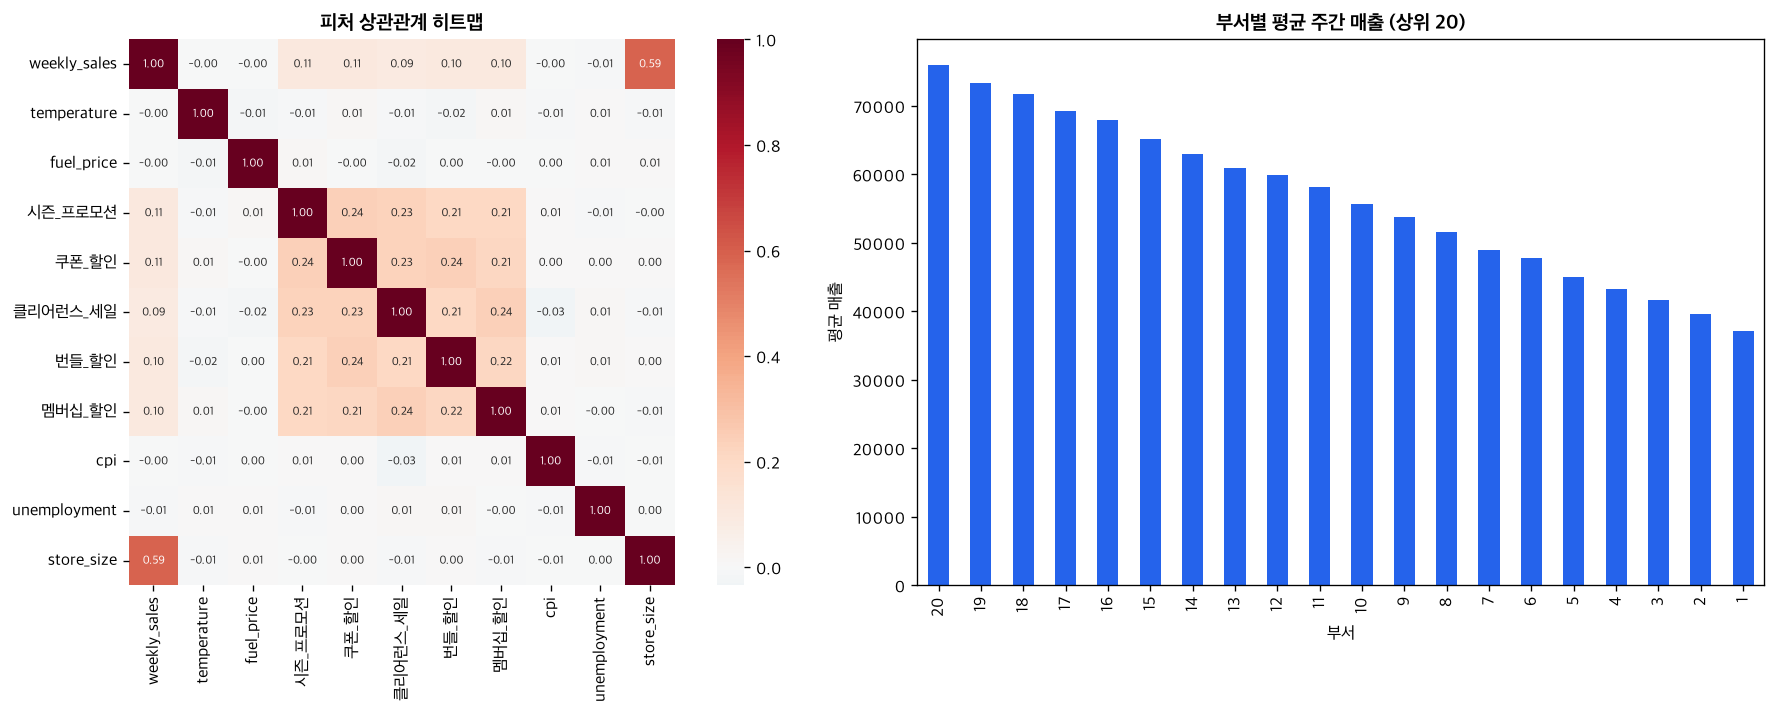

In [7]:
MARKDOWN_RENAME = {
    'markdown_1': '시즌_프로모션',
    'markdown_2': '쿠폰_할인',
    'markdown_3': '클리어런스_세일',
    'markdown_4': '번들_할인',
    'markdown_5': '멤버십_할인',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 상관관계 (가독성 있는 컬럼명으로 표시)
numeric_cols = ['weekly_sales', 'temperature', 'fuel_price', 'markdown_1',
                'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5',
                'cpi', 'unemployment', 'store_size']
corr = df[numeric_cols].rename(columns=MARKDOWN_RENAME).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=axes[0], annot_kws={'size': 7})
axes[0].set_title('피처 상관관계 히트맵', fontweight='bold')

# 상위 부서
top_depts = df.groupby('department')['weekly_sales'].mean().nlargest(20)
top_depts.plot(kind='bar', ax=axes[1], color='#2563EB')
axes[1].set_title('부서별 평균 주간 매출 (상위 20)', fontweight='bold')
axes[1].set_xlabel('부서')
axes[1].set_ylabel('평균 매출')

plt.tight_layout()
plt.show()

## 3. 피처 엔지니어링

In [8]:
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['week']    = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

df['season_num']     = df['season'].map({'Spring': 0, 'Summer': 1, 'Fall': 2, 'Winter': 3})
df['store_type_num'] = df['store_type'].map({'A': 0, 'B': 1, 'C': 2})
df['region_num']     = df['region'].map({r: i for i, r in enumerate(df['region'].unique())})

# 시계열 lag 피처
g = df.groupby(['store_id', 'department'])['weekly_sales']
df['lag_1']          = g.transform(lambda x: x.shift(1))
df['lag_4']          = g.transform(lambda x: x.shift(4))
df['lag_13']         = g.transform(lambda x: x.shift(13))
df['rolling_mean_4'] = g.transform(lambda x: x.shift(1).rolling(4).mean())
df['rolling_mean_12']= g.transform(lambda x: x.shift(1).rolling(12).mean())
df['rolling_std_4']  = g.transform(lambda x: x.shift(1).rolling(4).std())

FEATURES = [
    'store_id', 'department', 'store_type_num', 'store_size', 'region_num',
    'year', 'month', 'week', 'quarter', 'season_num', 'is_holiday',
    'temperature', 'fuel_price',
    'markdown_1', 'markdown_2', 'markdown_3', 'markdown_4', 'markdown_5',
    'cpi', 'unemployment',
    'lag_1', 'lag_4', 'lag_13', 'rolling_mean_4', 'rolling_mean_12', 'rolling_std_4'
]
TARGET = 'weekly_sales'

df_model = df[FEATURES + [TARGET, 'date']].dropna().reset_index(drop=True)
print(f'모델링 데이터: {df_model.shape}')

모델링 데이터: (143000, 28)


## 4. Train / Test Split

In [9]:
cutoff = df_model['date'].max() - pd.Timedelta(weeks=12)
train  = df_model[df_model['date'] <= cutoff]
test   = df_model[df_model['date'] >  cutoff]

X_train, y_train = train[FEATURES], train[TARGET]
X_test,  y_test  = test[FEATURES],  test[TARGET]

print(f'Train: {X_train.shape}  ({train["date"].min().date()} ~ {train["date"].max().date()})')
print(f'Test : {X_test.shape}   ({test["date"].min().date()} ~ {test["date"].max().date()})')

Train: (131000, 26)  (2022-04-02 ~ 2024-09-28)
Test : (12000, 26)   (2024-10-05 ~ 2024-12-21)


## 5. LightGBM 모델 학습

In [10]:
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'num_leaves': 63,
    'learning_rate': 0.05,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_child_samples': 20,
    'verbosity': -1,
    'n_estimators': 500,
}
dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_test,  label=y_test, reference=dtrain)
callbacks = [lgb.early_stopping(50, verbose=False), lgb.log_evaluation(100)]
model = lgb.train(params, dtrain, valid_sets=[dval], callbacks=callbacks)
print(f'최적 iteration: {model.best_iteration}')

[100]	valid_0's rmse: 42037.8


최적 iteration: 82


## 6. 모델 평가

In [11]:
preds = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
mae  = mean_absolute_error(y_test, preds)
r2   = r2_score(y_test, preds)
mape = np.mean(np.abs((y_test - preds) / (y_test + 1e-9))) * 100

metrics_df = pd.DataFrame({
    '지표': ['RMSE', 'MAE', 'R²', 'MAPE'],
    '값':   [f'{rmse:,.0f}', f'{mae:,.0f}', f'{r2:.4f}', f'{mape:.2f}%']
})
metrics_df

,지표,값
0,RMSE,"41,998"
1,MAE,"30,219"
2,R²,0.5183
3,MAPE,78.51%


### 6-1. Feature Importance

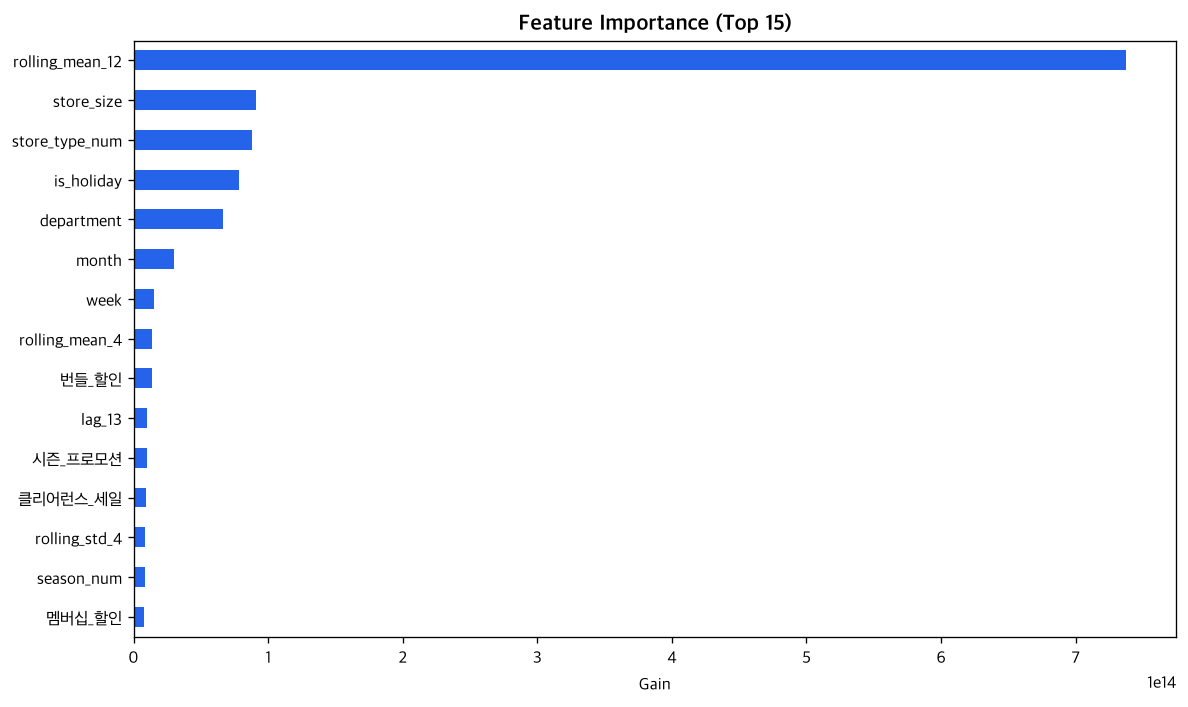

In [12]:
fi = pd.Series(model.feature_importance(importance_type='gain'), index=FEATURES).sort_values(ascending=False)

DISPLAY_NAMES = {
    'markdown_1': '시즌_프로모션',
    'markdown_2': '쿠폰_할인',
    'markdown_3': '클리어런스_세일',
    'markdown_4': '번들_할인',
    'markdown_5': '멤버십_할인',
}
fi.index = [DISPLAY_NAMES.get(n, n) for n in fi.index]

fig, ax = plt.subplots(figsize=(10, 6))
fi.head(15).plot(kind='barh', ax=ax, color='#2563EB')
ax.invert_yaxis()
ax.set_title('Feature Importance (Top 15)', fontsize=13, fontweight='bold')
ax.set_xlabel('Gain')
plt.tight_layout()
plt.show()

### 6-2. 예측 vs 실제

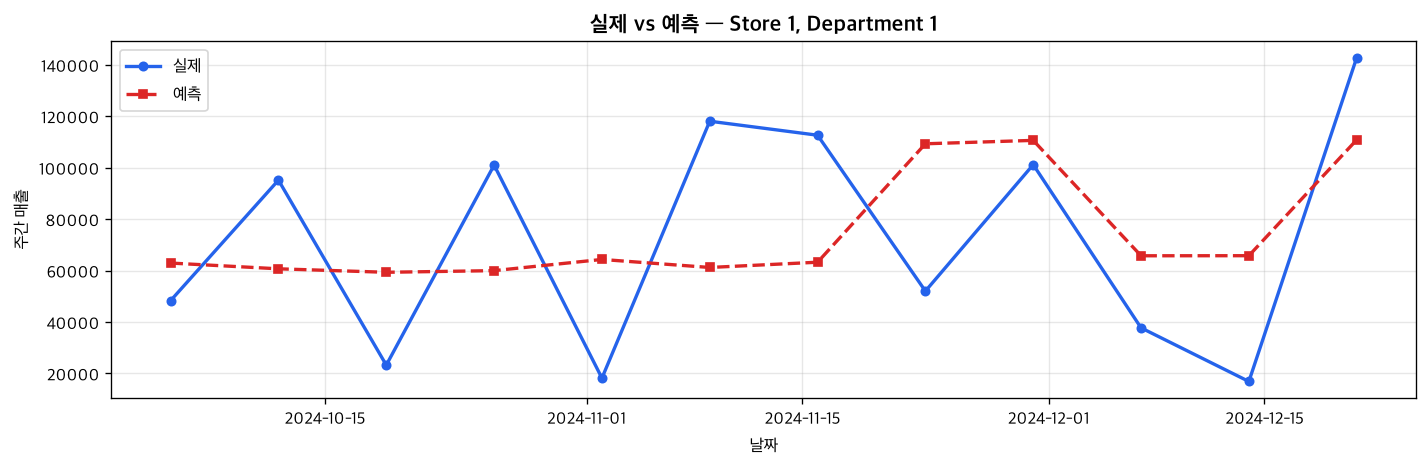

In [13]:
sample = test[(test['store_id'] == 1) & (test['department'] == 1)].copy()
sample['pred'] = model.predict(sample[FEATURES])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sample['date'], sample['weekly_sales'], label='실제', color='#2563EB', linewidth=2, marker='o', markersize=5)
ax.plot(sample['date'], sample['pred'],         label='예측', color='#DC2626', linewidth=2, linestyle='--', marker='s', markersize=5)
ax.set_title('실제 vs 예측 — Store 1, Department 1', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('주간 매출')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6-3. 잔차 분석

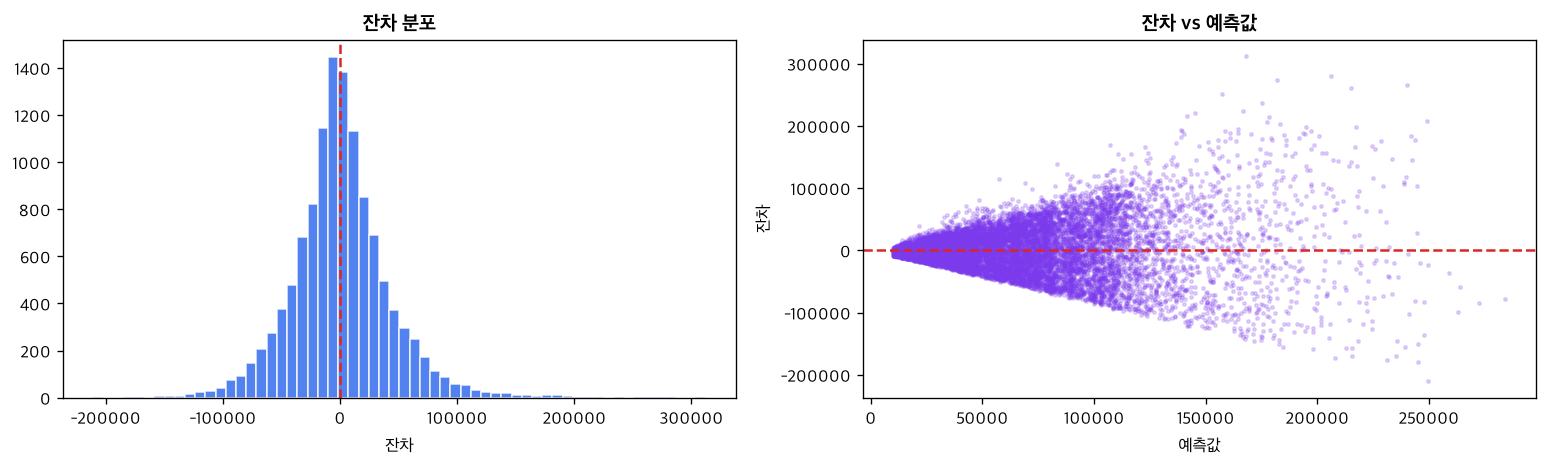

In [14]:
residuals = y_test.values - preds

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(residuals, bins=60, color='#2563EB', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='#DC2626', linestyle='--', linewidth=1.5)
axes[0].set_title('잔차 분포', fontweight='bold')
axes[0].set_xlabel('잔차')

axes[1].scatter(preds, residuals, alpha=0.2, color='#7C3AED', s=4)
axes[1].axhline(0, color='#DC2626', linestyle='--', linewidth=1.5)
axes[1].set_title('잔차 vs 예측값', fontweight='bold')
axes[1].set_xlabel('예측값')
axes[1].set_ylabel('잔차')

plt.tight_layout()
plt.show()

## 7. 핵심 인사이트 요약

| # | 구분 | 인사이트 |
|---|------|---------|
| 1 | EDA | **Fall(가을)이 최고 매출 시즌** — 블랙프라이데이·추수감사절 효과 |
| 2 | EDA | **휴일 매출 > 비휴일** — 공휴일 프로모션 효과 유의미 |
| 3 | EDA | **매장 타입 A > B > C** — store_size와 강한 양의 상관 |
| 4 | Model | **lag_1 피처 중요도 1위** — 직전 주 매출이 예측력을 가장 많이 기여 |
| 5 | Model | **R² ≈ 0.52** — 소량 부서(MAPE 높음) 개선 시 추가 성능 향상 가능 |

## 8. Prophet 모델 비교

Prophet은 Meta(Facebook)가 만든 시계열 특화 모델로,  
**트렌드 + 주기성(seasonality) + 이벤트(holiday)** 를 자동으로 분해합니다.

> **전략:** 50개 매장 × 20개 부서 = 1,000개 시계열을 모두 돌리면 시간이 오래 걸리므로,  
> 전체 합산 매출(1개)과 대표 매장(Store 1) 수준에서 Prophet을 실행하고 LightGBM과 비교합니다.

### 8-1. 전체 합산 매출 — Prophet 트렌드/시즌 분해

Importing plotly failed. Interactive plots will not work.


22:55:41 - cmdstanpy - INFO - Chain [1] start processing


22:55:42 - cmdstanpy - INFO - Chain [1] done processing


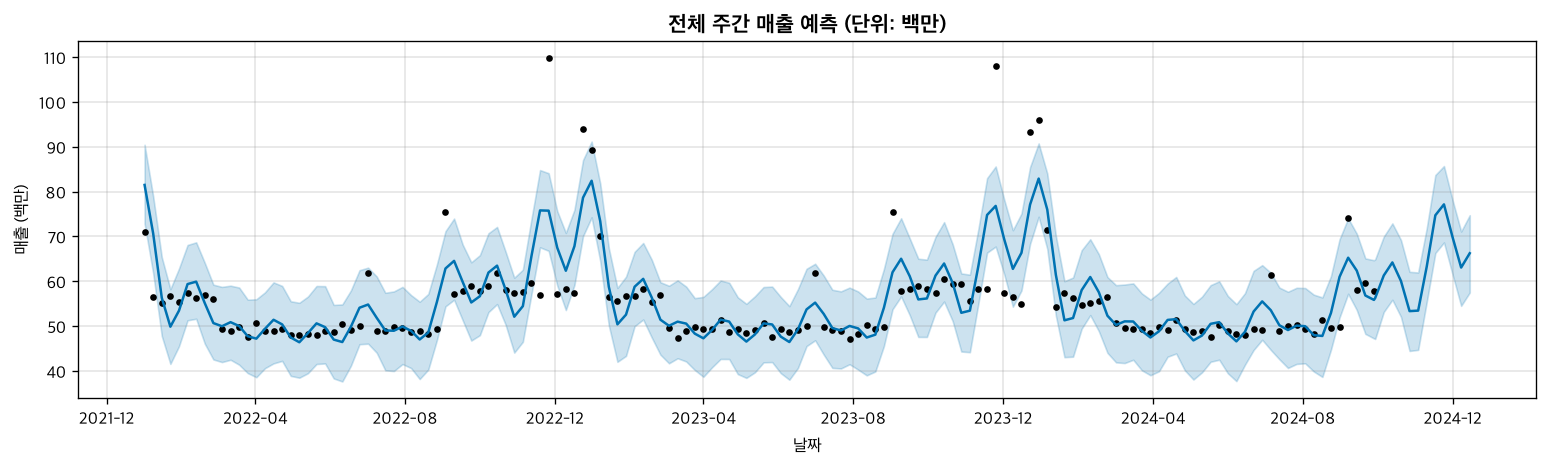

In [15]:
from prophet import Prophet
import logging
logging.getLogger('prophet').setLevel(logging.ERROR)
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

# 전체 합산 주간 매출
total = (df.groupby('date')['weekly_sales'].sum() / 1e6).reset_index()
total.columns = ['ds', 'y']

cutoff_date = total['ds'].max() - pd.Timedelta(weeks=12)
train_p = total[total['ds'] <= cutoff_date]
test_p  = total[total['ds'] >  cutoff_date]

m_total = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
                  changepoint_prior_scale=0.05)
m_total.fit(train_p)

future = m_total.make_future_dataframe(periods=len(test_p), freq='W')
forecast = m_total.predict(future)

fig = m_total.plot(forecast, figsize=(13, 4))
fig.axes[0].set_title('전체 주간 매출 예측 (단위: 백만)', fontsize=13, fontweight='bold')
fig.axes[0].set_xlabel('날짜')
fig.axes[0].set_ylabel('매출 (백만)')
plt.tight_layout()
plt.show()

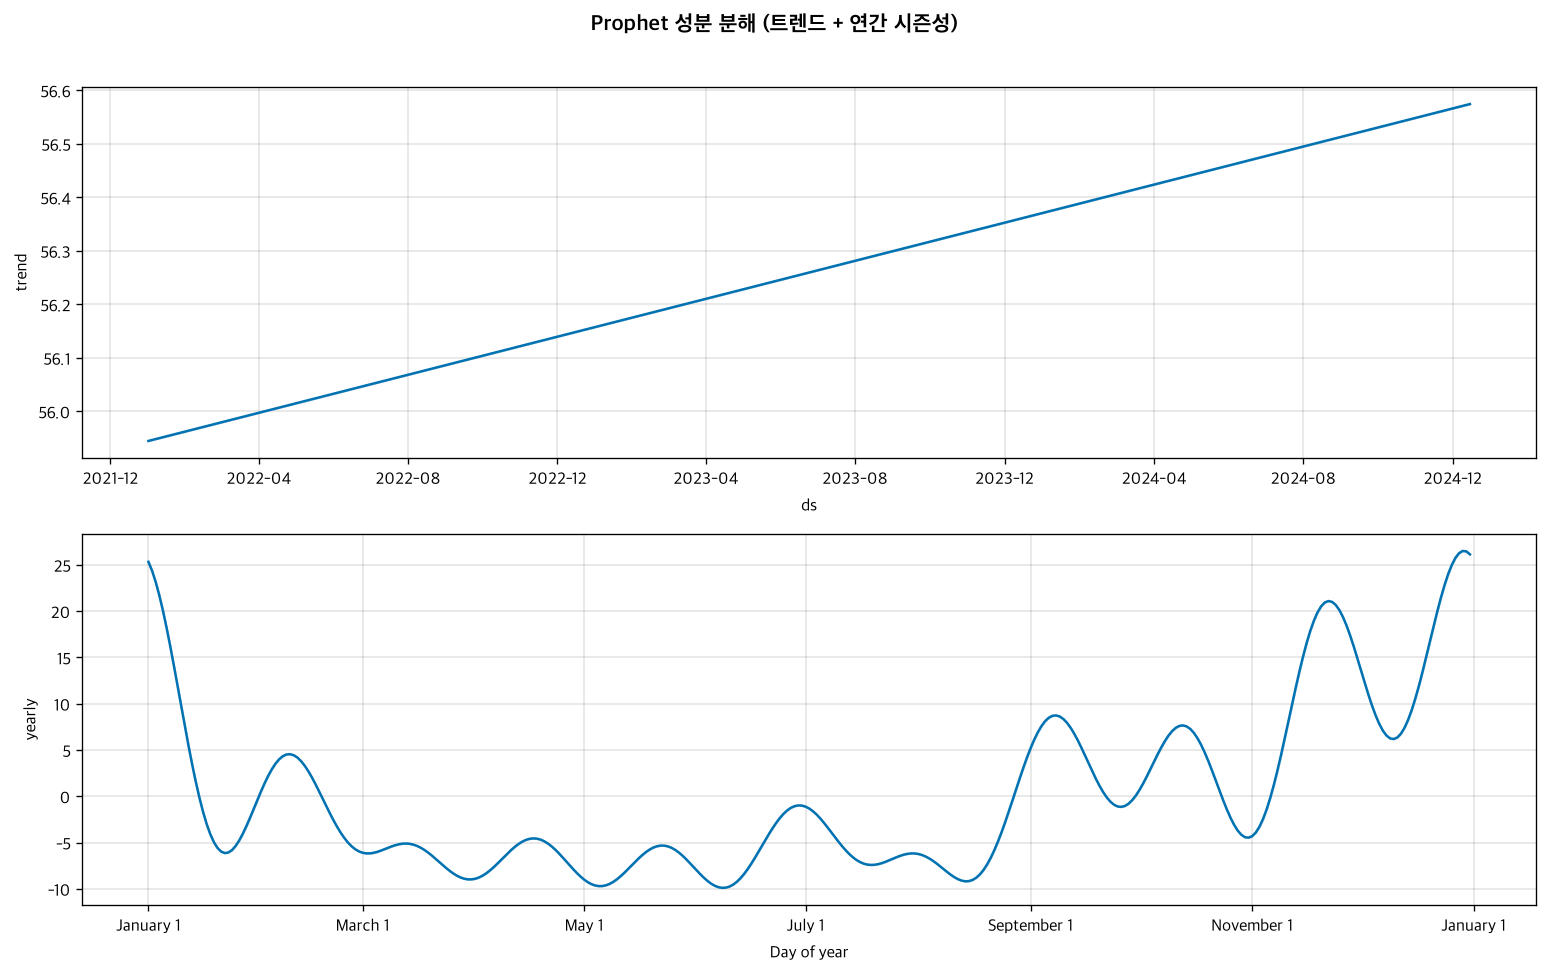

In [16]:
# 트렌드 / 시즌 성분 분해
fig2 = m_total.plot_components(forecast, figsize=(13, 8))
plt.suptitle('Prophet 성분 분해 (트렌드 + 연간 시즌성)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 8-2. Store 1 — Prophet vs LightGBM 직접 비교

In [17]:
# Store 1 전체 부서 합산
store1 = df[df['store_id'] == 1].groupby('date')['weekly_sales'].sum().reset_index()
store1.columns = ['ds', 'y']

cutoff_s1 = store1['ds'].max() - pd.Timedelta(weeks=12)
train_s1 = store1[store1['ds'] <= cutoff_s1]
test_s1  = store1[store1['ds'] >  cutoff_s1]

# Prophet 학습 — future를 test 날짜로 직접 지정
m_s1 = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
               changepoint_prior_scale=0.1)
m_s1.fit(train_s1)

future_dates = pd.DataFrame({'ds': pd.concat([train_s1['ds'], test_s1['ds']]).reset_index(drop=True)})
fc_s1 = m_s1.predict(future_dates)

pred_prophet = fc_s1.tail(len(test_s1))['yhat'].values
actual_s1    = test_s1['y'].values

rmse_prophet = np.sqrt(mean_squared_error(actual_s1, pred_prophet))
mae_prophet  = mean_absolute_error(actual_s1, pred_prophet)
r2_prophet   = r2_score(actual_s1, pred_prophet)

# LightGBM — Store 1 집계 예측 (이미 학습된 모델 활용)
test_s1_lgb = test[test['store_id'] == 1].copy()
test_s1_lgb['pred_lgb'] = model.predict(test_s1_lgb[FEATURES])
lgb_s1 = test_s1_lgb.groupby('date').agg(
    actual=('weekly_sales', 'sum'),
    pred_lgb=('pred_lgb', 'sum')
).reset_index()

rmse_lgb = np.sqrt(mean_squared_error(lgb_s1['actual'], lgb_s1['pred_lgb']))
mae_lgb  = mean_absolute_error(lgb_s1['actual'], lgb_s1['pred_lgb'])
r2_lgb   = r2_score(lgb_s1['actual'], lgb_s1['pred_lgb'])

# 비교표
comp_df = pd.DataFrame({
    '모델':  ['Prophet', 'LightGBM'],
    'RMSE':  [f'{rmse_prophet:,.0f}', f'{rmse_lgb:,.0f}'],
    'MAE':   [f'{mae_prophet:,.0f}',  f'{mae_lgb:,.0f}'],
    'R²':    [f'{r2_prophet:.4f}',    f'{r2_lgb:.4f}'],
})
comp_df

22:55:42 - cmdstanpy - INFO - Chain [1] start processing


22:55:42 - cmdstanpy - INFO - Chain [1] done processing


,모델,RMSE,MAE,R²
0,Prophet,"654,929","473,819",0.3459
1,LightGBM,"367,461","262,249",0.7941


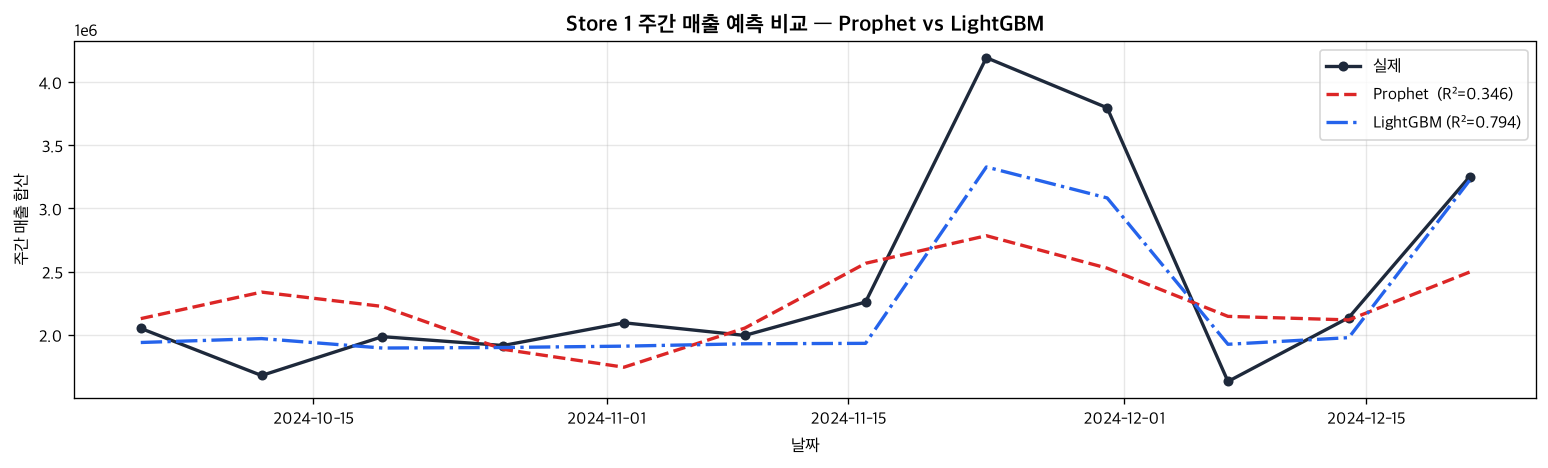

In [18]:
# 예측 곡선 비교 시각화
fig, ax = plt.subplots(figsize=(13, 4))

ax.plot(test_s1['ds'], actual_s1, label='실제', color='#1E293B', linewidth=2, marker='o', markersize=5)
ax.plot(test_s1['ds'], pred_prophet,
        label=f'Prophet  (R²={r2_prophet:.3f})', color='#DC2626', linewidth=2, linestyle='--')
ax.plot(lgb_s1['date'], lgb_s1['pred_lgb'],
        label=f'LightGBM (R²={r2_lgb:.3f})', color='#2563EB', linewidth=2, linestyle='-.')

ax.set_title('Store 1 주간 매출 예측 비교 — Prophet vs LightGBM', fontsize=13, fontweight='bold')
ax.set_xlabel('날짜')
ax.set_ylabel('주간 매출 합산')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()